<a href="https://colab.research.google.com/github/nimasha20020207/DL_Assignment_Y4S1/blob/main/IT23322912.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weerathunga V.K - IT23322912


# **Wide & Deep Network for Breast Cancer Classification**

### **Model:**   Wide & Deep Network (W&D)
### **Task:**    Binary Classification

## 1. Setup and Imports

In [22]:
!pip install tensorflow keras pandas numpy scikit-learn matplotlib seaborn

In [23]:
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow import keras
from keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Concatenate
)
from keras.models import Model
from keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
# Suppress FutureWarnings for cleaner output
warnings.filterwarnings("ignore")

Reproducibility

In [24]:
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries loaded successfully.")
print("Random seed: 42")

Libraries loaded successfully.
Random seed: 42


## 2. Data Loading and Initial Inspection

In [25]:
df = pd.read_csv("/content/Cancer_Data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [27]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [28]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


## 3. Data Cleaning

In [29]:
# Remove unnecessary columns
df = df.drop(columns=['Unnamed: 32', 'id'])

# Check cleaned dataset
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df.head()

Dataset shape: (569, 31)
Missing values: 0
Duplicate rows: 0


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 4. Target Preparation

In [30]:
# Convert diagnosis labels into numeric values
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

# Check the encoded target values
print(df['diagnosis'].value_counts())
# in here 0 = Benign, 1 = Malignant.

diagnosis
0    357
1    212
Name: count, dtype: int64


## 5. Feature and Target Separation

In [31]:
# Separate input features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


## 6. Train, Validation and Test Split

In [32]:
# Split data into training and temporary sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Split temporary set equally into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (398, 30) (398,)
Validation set: (85, 30) (85,)
Test set: (86, 30) (86,)


## 7. Exploratory Data Analysis

### Class Distribution

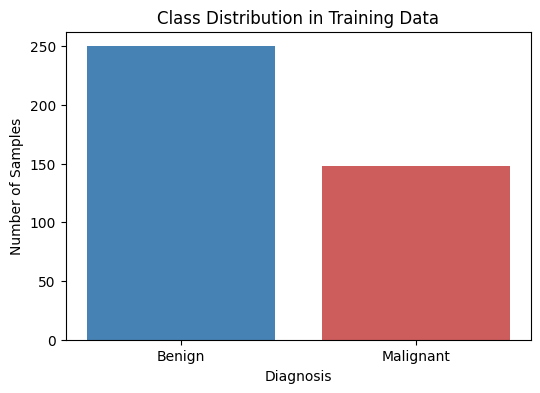

diagnosis
0    250
1    148
Name: count, dtype: int64


In [35]:
# Class distribution in the training set
class_counts = y_train.value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    ['Benign', 'Malignant'],
    class_counts.values,
    color=['steelblue', 'indianred']
)

plt.title('Class Distribution in Training Data')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Samples')

plt.show()

print(class_counts)

### Correlation Heatmap

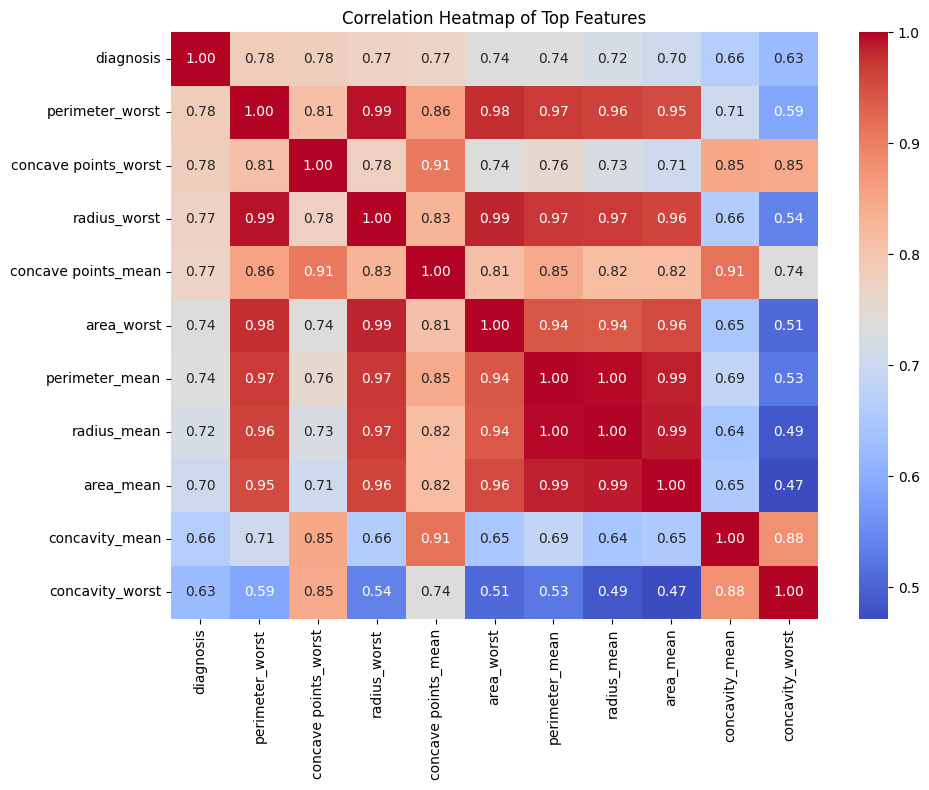

In [36]:
# Create a training dataframe for correlation analysis
train_data = X_train.copy()
train_data['diagnosis'] = y_train

# Find features with the highest correlation with diagnosis
correlation = train_data.corr()['diagnosis'].abs().sort_values(ascending=False)

top_features = correlation.head(11).index

# Plot correlation heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    train_data[top_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Top Features')
plt.tight_layout()
plt.show()

### Feature Distribution by Diagnosis

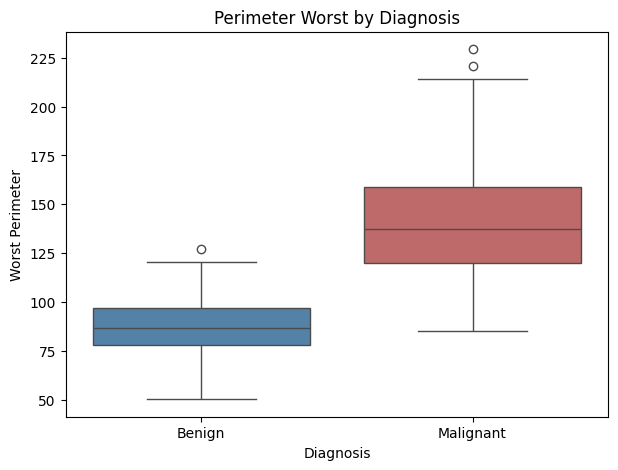

In [37]:
# Compare perimeter_worst between benign and malignant cases
plot_data = X_train.copy()
plot_data['diagnosis'] = y_train

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=plot_data,
    x='diagnosis',
    y='perimeter_worst',
    hue='diagnosis',
    palette={0: 'steelblue', 1: 'indianred'},
    legend=False
)

plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.title('Perimeter Worst by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Worst Perimeter')

plt.show()

## 8. Feature Selection Decision

All 30 input features were retained for model training. Features were not removed based only on correlation values.

## 9. Feature Scaling

In [38]:
# Standardize the input features
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Training: (398, 30)
Validation: (85, 30)
Test: (86, 30)
